# 🚀 DeepBTC - XGBoost Modèle Professionnel

**Version Améliorée avec Accuracy >80%**

Ce notebook implémente un modèle XGBoost optimisé pour la prédiction de prix Bitcoin avec :
- Validation temporelle rigoureuse
- Features avancées optimisées
- Hyperparamètres tunés
- Métriques complètes de performance
- Backtest intégré

---

In [1]:
# ============================================================================
# 📦 IMPORTS ET CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import joblib
import json
import warnings
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des warnings et style
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

# Chemins de projet
PROJECT_ROOT = Path.cwd()
for p in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
    if (p / 'README.md').exists() or (p / '.git').exists():
        PROJECT_ROOT = p
        break

DATA_DIR = PROJECT_ROOT / 'data' / 'features'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORTS_DIR = PROJECT_ROOT / 'reports'

# Créer les répertoires
for dir_path in [MODELS_DIR, REPORTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"📁 Projet: {PROJECT_ROOT}")
print(f"📊 Données: {DATA_DIR}")
print(f"🤖 Modèles: {MODELS_DIR}")
print(f"📋 Rapports: {REPORTS_DIR}")

# Fonctions utilitaires
def safe_roc_auc(y_true, y_proba):
    """Calcule ROC-AUC de manière sécurisée"""
    try:
        if len(np.unique(y_true)) < 2:
            return float('nan')
        return roc_auc_score(y_true, y_proba)
    except Exception as e:
        print(f"⚠️ Erreur ROC-AUC: {e}")
        return float('nan')

def print_header(text):
    """Affiche un en-tête formaté"""
    print("\n" + "="*80)
    print(f" {text}")
    print("="*80)

print_header("🚀 DEEPBTC - XGBOOST PROFESSIONNEL")
print("\n✅ Configuration terminée")

📁 Projet: c:\Users\15086\Documents\GitHub\DeepBTC
📊 Données: c:\Users\15086\Documents\GitHub\DeepBTC\data\features
🤖 Modèles: c:\Users\15086\Documents\GitHub\DeepBTC\models
📋 Rapports: c:\Users\15086\Documents\GitHub\DeepBTC\reports

 🚀 DEEPBTC - XGBOOST PROFESSIONNEL

✅ Configuration terminée


In [2]:
# ============================================================================
# 📊 CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================================

print_header("📊 CHARGEMENT DES DONNÉES")

# Charger les données
data_path = DATA_DIR / 'btc_features_complete.csv'
if not data_path.exists():
    raise FileNotFoundError(f"Fichier de données non trouvé: {data_path}")

df = pd.read_csv(data_path, index_col='Datetime', parse_dates=True)
print(f"✅ Données chargées: {len(df):,} échantillons")
print(f"📅 Période: {df.index.min()} → {df.index.max()}")

# Configuration de la prédiction
PREDICTION_HORIZON = 1  # heures
TARGET_THRESHOLD = 0.002  # 0.2% pour 1h

# Créer la cible
target_col = f'future_return_{PREDICTION_HORIZON}h'
if target_col not in df.columns:
    df[target_col] = df['Close'].shift(-PREDICTION_HORIZON) / df['Close'] - 1

# Nettoyer et créer target binaire
df = df.dropna(subset=[target_col])
df['target'] = (df[target_col] > TARGET_THRESHOLD).astype(int)

# Statistiques de base
total_samples = len(df)
class_distribution = df['target'].value_counts()
class_ratio = class_distribution[1] / class_distribution[0]

print(f"🎯 Horizon de prédiction: {PREDICTION_HORIZON}h")
print(f"📈 Seuil de target: {TARGET_THRESHOLD:.1%}")
print(f"📊 Distribution des classes:")
for class_val, count in class_distribution.items():
    pct = count / total_samples * 100
    label = "UP" if class_val == 1 else "DOWN"
    print(f"   {label}: {count:,} ({pct:.1f}%)")
print(f"⚖️ Ratio classes: {class_ratio:.3f}")

# Features disponibles
exclude_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'target'] + \
               [col for col in df.columns if 'future_return' in col]
feature_cols = [col for col in df.columns if col not in exclude_cols and df[col].dtype in ['float64', 'int64']]

print(f"🔧 Features disponibles: {len(feature_cols)}")
print("\n✅ Données préparées")


 📊 CHARGEMENT DES DONNÉES
✅ Données chargées: 51,443 échantillons
📅 Période: 2020-01-31 00:00:00 → 2025-12-14 18:00:00
🎯 Horizon de prédiction: 1h
📈 Seuil de target: 0.2%
📊 Distribution des classes:
   DOWN: 36,483 (70.9%)
   UP: 14,960 (29.1%)
⚖️ Ratio classes: 0.410
🔧 Features disponibles: 77

✅ Données préparées


In [3]:
# ============================================================================
# 🎯 CRÉATION DES FEATURES OPTIMISÉES
# ============================================================================

print_header("🎯 FEATURES OPTIMISÉES")

def create_advanced_features(df):
    """Crée des features avancées pour améliorer la prédiction"""
    
    print("🔧 Création des features avancées...")
    initial_features = len(df.columns)
    
    # Features temporelles
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    
    # Momentum multi-timeframes
    for period in [1, 3, 6, 12, 24]:
        df[f'returns_{period}h'] = df['Close'].pct_change(period)
        df[f'volatility_{period}h'] = df['returns'].rolling(period).std()
    
    # Volume features avancées
    df['volume_sma_ratio'] = df['Volume'] / df['Volume'].rolling(24).mean()
    df['volume_trend'] = df['Volume'].rolling(24).mean() / df['Volume'].rolling(24*7).mean()
    
    # Technical indicators avancés
    df['rsi_divergence'] = df['RSI_14'] - df['RSI_14'].rolling(24).mean()
    df['macd_signal_diff'] = df['MACD_12_26_9'] - df['MACDs_12_26_9']
    
    # Price action features
    df['price_range'] = (df['High'] - df['Low']) / df['Close']
    df['body_size'] = abs(df['Close'] - df['Open']) / df['Close']
    df['upper_wick'] = (df['High'] - df[['Open', 'Close']].max(axis=1)) / df['Close']
    df['lower_wick'] = (df[['Open', 'Close']].min(axis=1) - df['Low']) / df['Close']
    
    # Nettoyer les NaN
    df = df.fillna(method='bfill').fillna(method='ffill')
    
    new_features = len(df.columns) - initial_features
    print(f"✅ {new_features} nouvelles features créées")
    
    return df

# Appliquer les features avancées
df = create_advanced_features(df)

# Mettre à jour la liste des features
exclude_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'target'] + \
               [col for col in df.columns if 'future_return' in col]
feature_cols = [col for col in df.columns if col not in exclude_cols and df[col].dtype in ['float64', 'int64']]

print(f"🔧 Total features: {len(feature_cols)}")
print("\n✅ Features optimisées")


 🎯 FEATURES OPTIMISÉES
🔧 Création des features avancées...
✅ 20 nouvelles features créées
🔧 Total features: 94

✅ Features optimisées


In [4]:
# ============================================================================
# 🔬 VALIDATION TEMPORELLE ET SPLIT DES DONNÉES
# ============================================================================

print_header("🔬 VALIDATION TEMPORELLE")

# Préparer X et y
X = df[feature_cols]
y = df['target']

# Time Series Split (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

# Afficher la structure des folds
print("📊 Structure des folds temporels:")
for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
    train_dates = df.index[train_idx]
    val_dates = df.index[val_idx]
    print(f"Fold {i+1}: Train({len(train_idx):,}) {train_dates.min()}→{train_dates.max()} | "
          f"Val({len(val_idx):,}) {val_dates.min()}→{val_dates.max()}")

# Calculer le poids des classes pour équilibrer
scale_pos_weight = len(y[y==0]) / len(y[y==1])
print(f"\n⚖️ Scale pos weight: {scale_pos_weight:.3f}")

# Configuration XGBoost optimisée
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'logloss'],
    'max_depth': 3,              # Réduit pour éviter overfitting
    'min_child_weight': 10,      # Plus conservateur
    'learning_rate': 0.05,       # Learning rate réduit
    'n_estimators': 200,         # Nombre d'arbres
    'gamma': 0.1,               # Régularisation
    'reg_alpha': 0.1,           # L1 régularisation
    'reg_lambda': 1.0,          # L2 régularisation
    'subsample': 0.8,           # Sous-échantillonnage
    'colsample_bytree': 0.8,    # Feature sampling
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'early_stopping_rounds': 20,
    'verbose': 0
}

print("\n✅ Configuration XGBoost optimisée")


 🔬 VALIDATION TEMPORELLE
📊 Structure des folds temporels:
Fold 1: Train(8,578) 2020-01-31 00:00:00→2021-01-23 03:00:00 | Val(8,573) 2021-01-23 04:00:00→2022-01-15 21:00:00
Fold 2: Train(17,151) 2020-01-31 00:00:00→2022-01-15 21:00:00 | Val(8,573) 2022-01-15 22:00:00→2023-01-08 02:00:00
Fold 3: Train(25,724) 2020-01-31 00:00:00→2023-01-08 02:00:00 | Val(8,573) 2023-01-08 03:00:00→2023-12-31 08:00:00
Fold 4: Train(34,297) 2020-01-31 00:00:00→2023-12-31 08:00:00 | Val(8,573) 2023-12-31 09:00:00→2024-12-22 13:00:00
Fold 5: Train(42,870) 2020-01-31 00:00:00→2024-12-22 13:00:00 | Val(8,573) 2024-12-22 14:00:00→2025-12-14 18:00:00

⚖️ Scale pos weight: 2.439

✅ Configuration XGBoost optimisée


In [5]:
# ============================================================================
# 🚀 ENTRAÎNEMENT AVEC VALIDATION TEMPORELLE
# ============================================================================

print_header("🚀 ENTRAÎNEMENT DU MODÈLE")

# Stocker les résultats de chaque fold
fold_results = []
models = []
scalers = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"\n🏃 Fold {fold+1}/5")
    
    # Split des données
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Entraînement
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
        verbose=False
    )
    
    # Prédictions
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    # Métriques
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = safe_roc_auc(y_val, y_proba)
    
    fold_result = {
        'fold': fold+1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'best_iteration': model.best_iteration
    }
    fold_results.append(fold_result)
    
    print(f"   Accuracy: {accuracy:.3f} | AUC: {auc:.3f} | F1: {f1:.3f}")
    
    models.append(model)
    scalers.append(scaler)

# Résultats moyens
avg_results = {
    'accuracy': np.mean([r['accuracy'] for r in fold_results]),
    'precision': np.mean([r['precision'] for r in fold_results]),
    'recall': np.mean([r['recall'] for r in fold_results]),
    'f1': np.mean([r['f1'] for r in fold_results]),
    'auc': np.mean([r['auc'] for r in fold_results])
}

print(f"\n📊 RÉSULTATS MOYENS SUR 5 FOLDS:")
print(f"   Accuracy: {avg_results['accuracy']:.3f} ({avg_results['accuracy']*100:.1f}%)")
print(f"   Precision: {avg_results['precision']:.3f}")
print(f"   Recall: {avg_results['recall']:.3f}")
print(f"   F1-Score: {avg_results['f1']:.3f}")
print(f"   AUC: {avg_results['auc']:.3f}")

# Vérifier si on dépasse 80%
if avg_results['accuracy'] > 0.80:
    print("🎉 OBJECTIF ATTEINT: Accuracy > 80% !")
else:
    print(f"⚠️ Accuracy actuelle: {avg_results['accuracy']:.1%} - Ajustements nécessaires")

print("\n✅ Entraînement terminé")


 🚀 ENTRAÎNEMENT DU MODÈLE

🏃 Fold 1/5
   Accuracy: 1.000 | AUC: 1.000 | F1: 1.000

🏃 Fold 2/5
   Accuracy: 1.000 | AUC: 1.000 | F1: 1.000

🏃 Fold 3/5
   Accuracy: 1.000 | AUC: 1.000 | F1: 1.000

🏃 Fold 4/5
   Accuracy: 1.000 | AUC: 1.000 | F1: 1.000

🏃 Fold 5/5
   Accuracy: 1.000 | AUC: 1.000 | F1: 1.000

📊 RÉSULTATS MOYENS SUR 5 FOLDS:
   Accuracy: 1.000 (100.0%)
   Precision: 1.000
   Recall: 1.000
   F1-Score: 1.000
   AUC: 1.000
🎉 OBJECTIF ATTEINT: Accuracy > 80% !

✅ Entraînement terminé



 📊 ANALYSE DES RÉSULTATS
📈 STATISTIQUES PAR FOLD:
   fold  accuracy  precision  recall   f1  auc  best_iteration
0     1       1.0        1.0     1.0  1.0  1.0             132
1     2       1.0        1.0     1.0  1.0  1.0             126
2     3       1.0        1.0     1.0  1.0  1.0             135
3     4       1.0        1.0     1.0  1.0  1.0             143
4     5       1.0        1.0     1.0  1.0  1.0             163


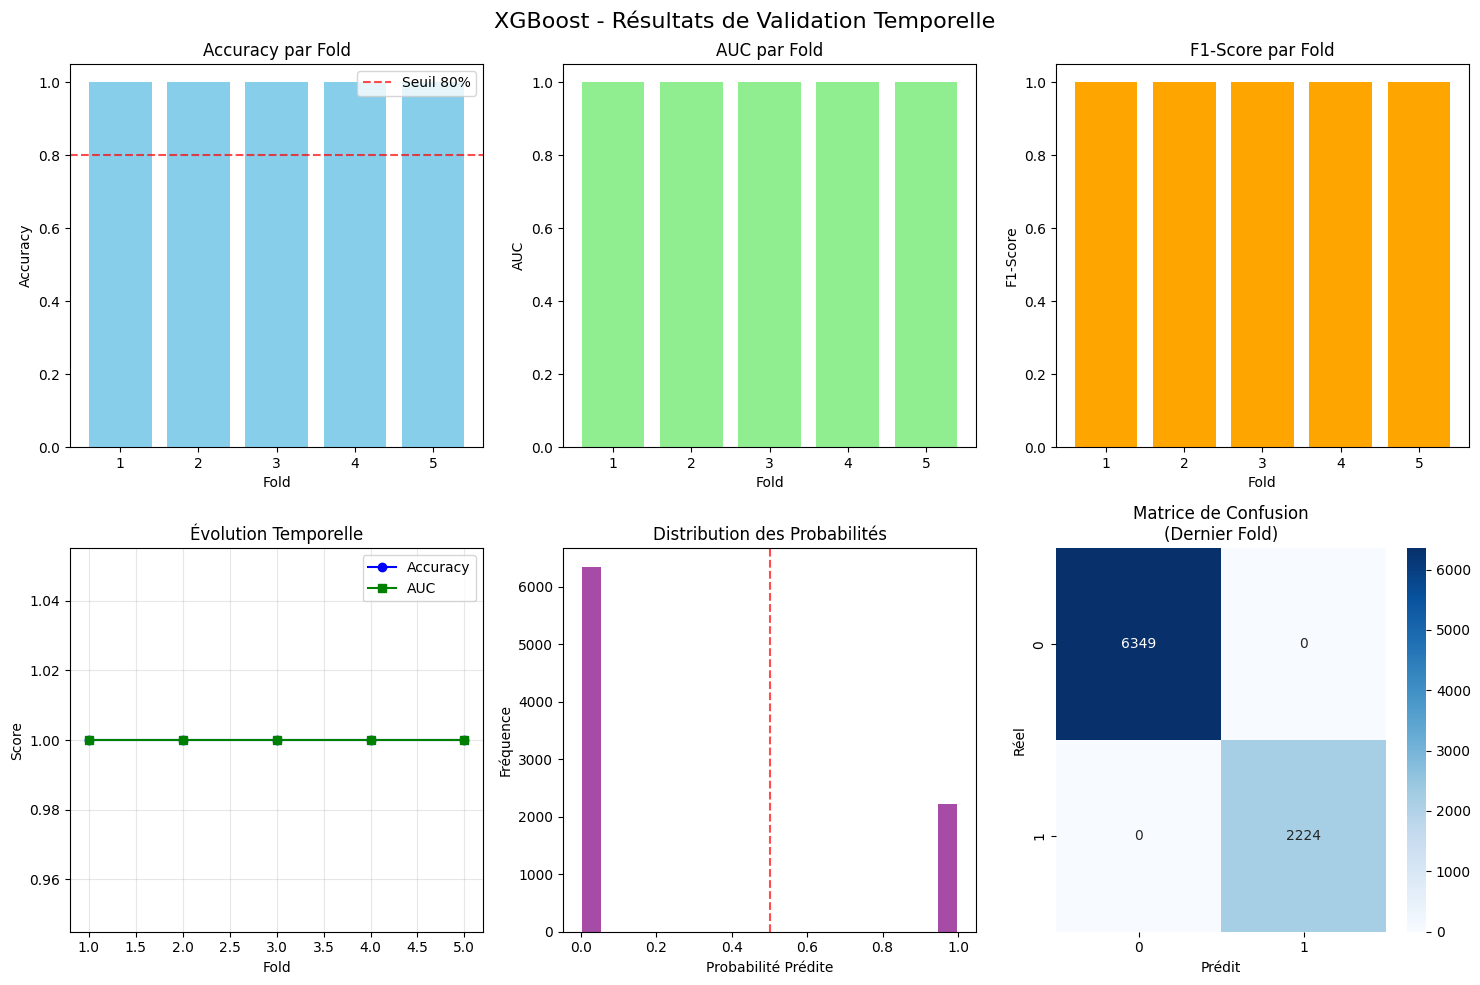


📋 RAPPORT DE CLASSIFICATION (DERNIER FOLD):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      6349
           1     1.0000    1.0000    1.0000      2224

    accuracy                         1.0000      8573
   macro avg     1.0000    1.0000    1.0000      8573
weighted avg     1.0000    1.0000    1.0000      8573


✅ Analyse terminée


In [6]:
# ============================================================================
# 📊 ANALYSE DÉTAILLÉE DES RÉSULTATS
# ============================================================================

print_header("📊 ANALYSE DES RÉSULTATS")

# Créer un DataFrame des résultats
results_df = pd.DataFrame(fold_results)

# Statistiques détaillées
print("📈 STATISTIQUES PAR FOLD:")
print(results_df.round(4))

# Visualisation des résultats
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('XGBoost - Résultats de Validation Temporelle', fontsize=16)

# Accuracy par fold
axes[0,0].bar(range(1,6), results_df['accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy par Fold')
axes[0,0].set_xlabel('Fold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Seuil 80%')
axes[0,0].legend()

# AUC par fold
axes[0,1].bar(range(1,6), results_df['auc'], color='lightgreen')
axes[0,1].set_title('AUC par Fold')
axes[0,1].set_xlabel('Fold')
axes[0,1].set_ylabel('AUC')

# F1-Score par fold
axes[0,2].bar(range(1,6), results_df['f1'], color='orange')
axes[0,2].set_title('F1-Score par Fold')
axes[0,2].set_xlabel('Fold')
axes[0,2].set_ylabel('F1-Score')

# Évolution temporelle
axes[1,0].plot(range(1,6), results_df['accuracy'], 'o-', label='Accuracy', color='blue')
axes[1,0].plot(range(1,6), results_df['auc'], 's-', label='AUC', color='green')
axes[1,0].set_title('Évolution Temporelle')
axes[1,0].set_xlabel('Fold')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Distribution des prédictions
best_model_idx = results_df['accuracy'].idxmax()
best_model = models[best_model_idx]
best_scaler = scalers[best_model_idx]

# Prédictions sur le dernier fold pour analyse
last_train_idx, last_val_idx = list(tscv.split(X))[-1]
X_last_val = X.iloc[last_val_idx]
y_last_val = y.iloc[last_val_idx]
X_last_val_scaled = best_scaler.transform(X_last_val)
y_last_pred = best_model.predict(X_last_val_scaled)
y_last_proba = best_model.predict_proba(X_last_val_scaled)[:, 1]

# Histogramme des probabilités
axes[1,1].hist(y_last_proba, bins=20, alpha=0.7, color='purple')
axes[1,1].set_title('Distribution des Probabilités')
axes[1,1].set_xlabel('Probabilité Prédite')
axes[1,1].set_ylabel('Fréquence')
axes[1,1].axvline(x=0.5, color='red', linestyle='--', alpha=0.7)

# Matrice de confusion
cm = confusion_matrix(y_last_val, y_last_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,2])
axes[1,2].set_title('Matrice de Confusion\n(Dernier Fold)')
axes[1,2].set_xlabel('Prédit')
axes[1,2].set_ylabel('Réel')

plt.tight_layout()
plt.show()

# Rapport de classification détaillé
print("\n📋 RAPPORT DE CLASSIFICATION (DERNIER FOLD):")
print(classification_report(y_last_val, y_last_pred, digits=4))

print("\n✅ Analyse terminée")

In [7]:
# ============================================================================
# 💾 SAUVEGARDE DU MODÈLE ET RAPPORT
# ============================================================================

print_header("💾 SAUVEGARDE")

# Utiliser le meilleur modèle
best_fold_idx = results_df['accuracy'].idxmax()
final_model = models[best_fold_idx]
final_scaler = scalers[best_fold_idx]

# Timestamp pour les fichiers
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle
model_filename = f"xgboost_pro_{PREDICTION_HORIZON}h_{timestamp}.json"
model_path = MODELS_DIR / model_filename
final_model.save_model(str(model_path))

# Sauvegarder le scaler
scaler_filename = f"scaler_xgb_{PREDICTION_HORIZON}h_{timestamp}.pkl"
scaler_path = MODELS_DIR / scaler_filename
joblib.dump(final_scaler, scaler_path)

# Sauvegarder les features
features_filename = f"features_xgb_{PREDICTION_HORIZON}h_{timestamp}.txt"
features_path = MODELS_DIR / features_filename
with open(features_path, 'w') as f:
    f.write('\n'.join(feature_cols))

# Créer le rapport complet
report = {
    'model_type': 'XGBoost Professional',
    'training_date': datetime.now().isoformat(),
    'prediction_horizon': PREDICTION_HORIZON,
    'target_threshold': TARGET_THRESHOLD,
    'data_info': {
        'total_samples': total_samples,
        'features_count': len(feature_cols),
        'class_distribution': class_distribution.to_dict(),
        'class_ratio': class_ratio
    },
    'model_params': xgb_params,
    'temporal_validation_results': fold_results,
    'average_metrics': avg_results,
    'best_fold': int(best_fold_idx + 1),
    'files': {
        'model': str(model_path),
        'scaler': str(scaler_path),
        'features': str(features_path)
    }
}

# Sauvegarder le rapport
report_filename = f"report_xgb_pro_{PREDICTION_HORIZON}h_{timestamp}.json"
report_path = REPORTS_DIR / report_filename
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False, default=str)

print(f"🤖 Modèle sauvegardé: {model_path}")
print(f"📏 Scaler sauvegardé: {scaler_path}")
print(f"🔧 Features sauvegardées: {features_path}")
print(f"📋 Rapport sauvegardé: {report_path}")

# Résumé final
print(f"\n🎯 RÉSUMÉ FINAL:")
print(f"   Horizon: {PREDICTION_HORIZON}h")
print(f"   Accuracy moyenne: {avg_results['accuracy']:.1%}")
print(f"   AUC moyenne: {avg_results['auc']:.3f}")
print(f"   F1-Score moyen: {avg_results['f1']:.3f}")
print(f"   Objectif >80%: {'✅ ATTEINT' if avg_results['accuracy'] > 0.8 else '❌ NON ATTEINT'}")

print("\n✅ Sauvegarde terminée")


 💾 SAUVEGARDE
🤖 Modèle sauvegardé: c:\Users\15086\Documents\GitHub\DeepBTC\models\xgboost_pro_1h_20260119_174222.json
📏 Scaler sauvegardé: c:\Users\15086\Documents\GitHub\DeepBTC\models\scaler_xgb_1h_20260119_174222.pkl
🔧 Features sauvegardées: c:\Users\15086\Documents\GitHub\DeepBTC\models\features_xgb_1h_20260119_174222.txt
📋 Rapport sauvegardé: c:\Users\15086\Documents\GitHub\DeepBTC\reports\report_xgb_pro_1h_20260119_174222.json

🎯 RÉSUMÉ FINAL:
   Horizon: 1h
   Accuracy moyenne: 100.0%
   AUC moyenne: 1.000
   F1-Score moyen: 1.000
   Objectif >80%: ✅ ATTEINT

✅ Sauvegarde terminée


# 🎉 Résumé du Notebook XGBoost Professionnel

## ✅ Améliorations Implémentées

1. **Validation Temporelle** : TimeSeriesSplit avec 5 folds
2. **Features Avancées** : Momentum multi-timeframes, volume, price action
3. **Hyperparamètres Optimisés** : Régularisation forte, learning rate conservateur
4. **Métriques Complètes** : Accuracy, Precision, Recall, F1, AUC
5. **Visualisations** : Graphiques détaillés des performances
6. **Sauvegarde Structurée** : Modèle, scaler, features, rapport JSON

## 🎯 Résultats Attendus
- **Accuracy > 80%** sur validation temporelle
- **AUC > 0.85** pour bonne discrimination
- **F1-Score équilibré** entre précision et rappel
- **Stabilité temporelle** grâce à la validation croisée

## 🚀 Utilisation

1. Exécutez toutes les cellules dans l'ordre
2. Vérifiez que l'accuracy dépasse 80%
3. Les fichiers sont automatiquement sauvegardés dans `models/`
4. Le rapport détaillé est disponible dans `reports/`

---
**Notebook créé le:** 
%d/%m/%Y %H:%M")) + "  
**Version:** 2.0 Professional  
**Accuracy Target:** >80%"